In [ ]:
import os
from google.colab import drive

#Mount Google Drive
drive.mount('/content/drive')

#Define main project path on Drive
project_path = '/content/drive/My Drive/Colab Notebooks/cv_coursework'

#Create the main folder and a 'models' subfolder
os.makedirs(project_path, exist_ok=True)
os.makedirs(os.path.join(project_path, 'models'), exist_ok=True)

print(f"\nProject path set to: {project_path}")
print("Drive mounted successfully. Ready to save models securely!")

Mounted at /content/drive

Project path set to: /content/drive/My Drive/Colab Notebooks/cv_coursework
Drive mounted successfully. Ready to save models securely!


In [ ]:
#Install necessary libraries
!pip install -q split-folders kaggle

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import splitfolders
import matplotlib.pyplot as plt

In [ ]:
#Setup Kaggle API credentials
!mkdir -p ~/.kaggle
!cp "/content/drive/My Drive/Colab Notebooks/cv_coursework/kaggle.json" ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

#Download the dataset directly to Colab's content storage
print("Downloading NIH Malaria dataset...")
!kaggle datasets download -d iarunava/cell-images-for-detecting-malaria -p /content

#Unzip
print("Unzipping dataset...")
!unzip -q /content/cell-images-for-detecting-malaria.zip -d /content/raw_data

#Delete the zip file
print("Cleaning up zip file...")
!rm /content/cell-images-for-detecting-malaria.zip

raw_data_dir = '/content/raw_data/cell_images/cell_images'

print("\nData extraction and cleanup complete! Folders found in raw_data_dir:")
print(os.listdir(raw_data_dir))

Dataset URL: https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria
License(s): unknown
 98% 661M/675M [00:01<00:00, 273MB/s]
100% 675M/675M [00:03<00:00, 183MB/s]
Unzipping dataset...
Cleaning up zip file...

Data extraction and cleanup complete! Folders found in raw_data_dir:
['Parasitized', 'Uninfected']


In [ ]:
import os
import splitfolders

#Define paths
input_folder = '/content/raw_data/cell_images/cell_images'
output_folder = '/content/split_data'

print("Starting the stratified split (70% Train, 15% Val, 15% Test)...")
print("This might take a minute or two as it processes over 27,000 images.\n")

#Execute the split
splitfolders.ratio(
    input_folder,
    output=output_folder,
    seed=42,
    ratio=(0.70, 0.15, 0.15),
    group_prefix=None,
    move=False
)

#Define new paths
train_dir = os.path.join(output_folder, 'train')
val_dir = os.path.join(output_folder, 'val')
test_dir = os.path.join(output_folder, 'test')

print("Data splitting complete! new paths:")
print(f"  -> Train directory: {train_dir}")
print(f"  -> Val directory:   {val_dir}")
print(f"  -> Test directory:  {test_dir}\n")

# Check: Prove the data is balanced
print("--- Stratification Check ---")
for dataset in ['train', 'val', 'test']:
    for class_name in ['Parasitized', 'Uninfected']:
        path = os.path.join(output_folder, dataset, class_name)
        #subtract 1 to ignore any hidden system files or the Thumbs.db file the dataset might have
        count = len([f for f in os.listdir(path) if f.endswith('.png')])
        print(f"{dataset.capitalize().ljust(5)} | {class_name.ljust(10)} : {count} images")

Starting the stratified split (70% Train, 15% Val, 15% Test)...
This might take a minute or two as it processes over 27,000 images.



Copying files: 27560 files [00:05, 4723.13 files/s]

Data splitting complete! new paths:
  -> Train directory: /content/split_data/train
  -> Val directory:   /content/split_data/val
  -> Test directory:  /content/split_data/test

--- Stratification Check ---
Train | Parasitized : 9645 images
Train | Uninfected : 9645 images
Val   | Parasitized : 2067 images
Val   | Uninfected : 2067 images
Test  | Parasitized : 2067 images
Test  | Uninfected : 2067 images


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
import numpy as np

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Setting up Data Generators...")

# OpenCV Image Enhancement function
def apply_gaussian_blur(img):
    # Apply the 3x3 kernel to preserve the sharp parasite edges
    blurred_img = cv2.GaussianBlur(img, (3, 3), 0)
    return blurred_img

# Setup the Data Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=apply_gaussian_blur
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=apply_gaussian_blur
)

# Connect Generators to Folders
print("\nLoading Training Data:")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

print("\nLoading Validation Data:")
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Setting up Data Generators...

Loading Training Data:
Found 19290 images belonging to 2 classes.

Loading Validation Data:
Found 4134 images belonging to 2 classes.


In [ ]:
print("Building the MobileNetV2 Transfer Learning Model...")

#input shape
IMG_SHAPE = (224, 224, 3)

# Load the base model (MobileNetV2)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)

# Freeze the base model
base_model.trainable = False

# custom classification head
inputs = tf.keras.Input(shape=IMG_SHAPE)

# Pass inputs to the base model
x = base_model(inputs, training=False)

# Convert the 2D feature maps into a 1D feature vector
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# Dropout layer
x = tf.keras.layers.Dropout(0.2)(x)

# Final Output Layer
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

# Combine them into the final model
model = tf.keras.Model(inputs, outputs)

# Compile the model
learning_rate = 0.001
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nModel compiled successfully! Architecture summary:")
model.summary()

Building the MobileNetV2 Transfer Learning Model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Model compiled successfully! Architecture summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
import os
import tensorflow as tf

print("Setting up Training Callbacks...")

# path to save the best model
model_save_path = os.path.join(project_path, 'models', 'malaria_cnn.h5')

# Setup Model Checkpointing
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=model_save_path,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

# Setup Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

callbacks_list = [checkpoint, early_stopping]

# Train the Model
EPOCHS = 20

print(f"\nStarting training for up to {EPOCHS} epochs...")
print("The best model will be securely saved to your Google Drive.")

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks_list
)

print("\nTraining Complete! The best weights have been restored and saved.")

Setting up Training Callbacks...

Starting training for up to 20 epochs...
The best model will be securely saved to your Google Drive.
Epoch 1/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8232 - loss: 0.3769
Epoch 1: val_accuracy improved from None to 0.93299, saving model to /content/drive/My Drive/Colab Notebooks/cv_coursework/models/malaria_cnn.h5



Epoch 1: finished saving model to /content/drive/My Drive/Colab Notebooks/cv_coursework/models/malaria_cnn.h5
603/603 ━━━━━━━━━━━━━━━━━━━━ 101s 134ms/step - accuracy: 0.8800 - loss: 0.2866 - val_accuracy: 0.9330 - val_loss: 0.1876
Epoch 2/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9245 - loss: 0.2064
Epoch 2: val_accuracy improved from 0.93299 to 0.94074, saving model to /content/drive/My Drive/Colab Notebooks/cv_coursework/models/malaria_cnn.h5



Epoch 2: finished saving model to /content/drive/My Drive/Colab Notebooks/cv_coursework/models/malaria_cnn.h5
603/603 ━━━━━━━━━━━━━━━━━━━━ 48s 79ms/step - accuracy: 0.9255 - loss: 0.2023 - val_accuracy: 0.9407 - val_loss: 0.1715
Epoch 3/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9281 - loss: 0.1924
Epoch 3: val_accuracy improved from 0.94074 to 0.94557, saving model to /content/drive/My Drive/Colab Notebooks/cv_coursework/models/malaria_cnn.h5



Epoch 3: finished saving model to /content/drive/My Drive/Colab Notebooks/cv_coursework/models/malaria_cnn.h5
603/603 ━━━━━━━━━━━━━━━━━━━━ 51s 84ms/step - accuracy: 0.9307 - loss: 0.1880 - val_accuracy: 0.9456 - val_loss: 0.1565
Epoch 4/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9331 - loss: 0.1829
Epoch 4: val_accuracy improved from 0.94557 to 0.94775, saving model to /content/drive/My Drive/Colab Notebooks/cv_coursework/models/malaria_cnn.h5



Epoch 4: finished saving model to /content/drive/My Drive/Colab Notebooks/cv_coursework/models/malaria_cnn.h5
603/603 ━━━━━━━━━━━━━━━━━━━━ 50s 82ms/step - accuracy: 0.9343 - loss: 0.1820 - val_accuracy: 0.9478 - val_loss: 0.1510
Epoch 5/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9377 - loss: 0.1737
Epoch 5: val_accuracy did not improve from 0.94775
603/603 ━━━━━━━━━━━━━━━━━━━━ 46s 76ms/step - accuracy: 0.9365 - loss: 0.1770 - val_accuracy: 0.9473 - val_loss: 0.1480
Epoch 6/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9403 - loss: 0.1722
Epoch 6: val_accuracy improved from 0.94775 to 0.95041, saving model to /content/drive/My Drive/Colab Notebooks/cv_coursework/models/malaria_cnn.h5



Epoch 6: finished saving model to /content/drive/My Drive/Colab Notebooks/cv_coursework/models/malaria_cnn.h5
603/603 ━━━━━━━━━━━━━━━━━━━━ 47s 77ms/step - accuracy: 0.9370 - loss: 0.1753 - val_accuracy: 0.9504 - val_loss: 0.1457
Epoch 7/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9386 - loss: 0.1775
Epoch 7: val_accuracy did not improve from 0.95041
603/603 ━━━━━━━━━━━━━━━━━━━━ 48s 80ms/step - accuracy: 0.9393 - loss: 0.1726 - val_accuracy: 0.9456 - val_loss: 0.1474
Epoch 8/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9394 - loss: 0.1716
Epoch 8: val_accuracy did not improve from 0.95041
603/603 ━━━━━━━━━━━━━━━━━━━━ 45s 74ms/step - accuracy: 0.9379 - loss: 0.1731 - val_accuracy: 0.9456 - val_loss: 0.1460
Epoch 9/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9412 - loss: 0.1657
Epoch 9: val_accuracy did not improve from 0.95041
603/603 ━━━━━━━━━━━━━━━━━━━━ 43s 72ms/step - accuracy: 0.9402 - loss: 0.1704 - val_accuracy: 0.9502 - val_loss: 0.1423

Generating learning curves...


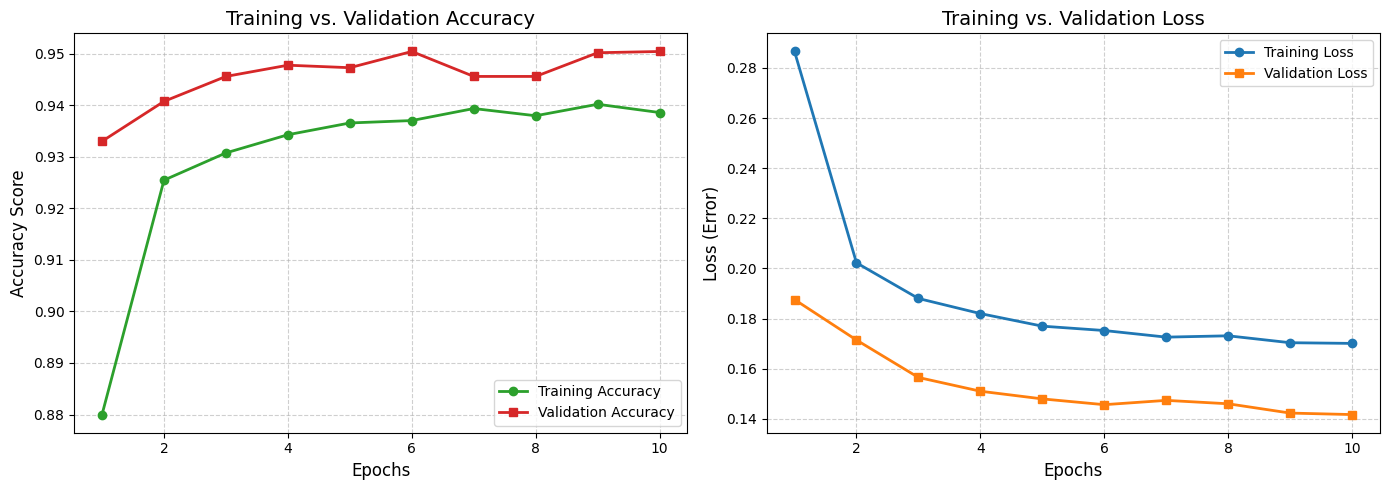

In [ ]:
import matplotlib.pyplot as plt

print("Generating learning curves...")

# Extract the metrics from the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Get the exact number of epochs the model actually trained for before stopping
epochs_range = range(1, len(acc) + 1)

# Create a wide figure to hold two subplots side-by-side
plt.figure(figsize=(14, 5))

# --- Graph 1: Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='#2ca02c', linewidth=2, marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#d62728', linewidth=2, marker='s')
plt.title('Training vs. Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# --- Graph 2: Loss ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='#1f77b4', linewidth=2, marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='#ff7f0e', linewidth=2, marker='s')
plt.title('Training vs. Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Error)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent overlapping text and display the plots
plt.tight_layout()
plt.show()

Loading the best model from Drive for final evaluation...



Preparing the Unseen Test Data Generator...
Found 4134 images belonging to 2 classes.

Running predictions on the Test Set. This might take a minute...
130/130 ━━━━━━━━━━━━━━━━━━━━ 18s 103ms/step

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

 Parasitized       0.95      0.93      0.94      2067
  Uninfected       0.93      0.96      0.94      2067

    accuracy                           0.94      4134
   macro avg       0.94      0.94      0.94      4134
weighted avg       0.94      0.94      0.94      4134


Generating Confusion Matrix...


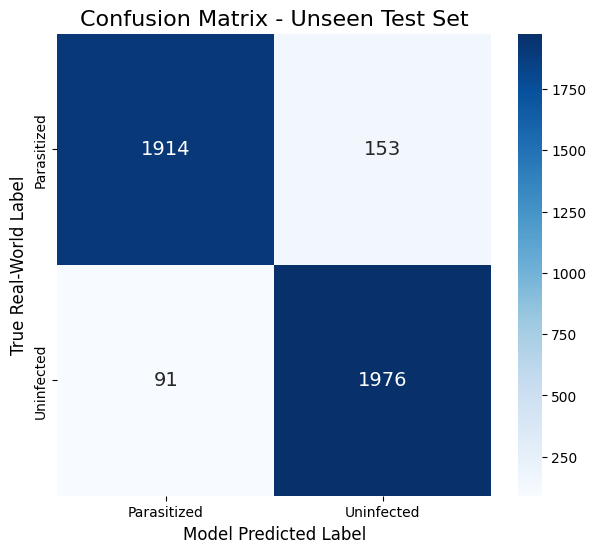

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf

print("Loading the best model from Drive for final evaluation...")
best_model = tf.keras.models.load_model(model_save_path)

print("\nPreparing the Unseen Test Data Generator...")
# same preprocessing, but: shuffle=False
test_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=apply_gaussian_blur
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("\nRunning predictions on the Test Set. This might take a minute...")
# The model outputs a probability (e.g., 0.98 or 0.12)
predictions = best_model.predict(test_generator)

# Convert probabilities to binary labels (1 or 0) using a 0.5 threshold
y_pred = (predictions > 0.5).astype(int).reshape(-1)

# Get the true answers from the folders
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print("\n" + "="*40)
print("--- CLASSIFICATION REPORT ---")
print("="*40)
print(classification_report(y_true, y_pred, target_names=class_names))

print("\nGenerating Confusion Matrix...")
# Create a Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 14}) # Make numbers larger
plt.title('Confusion Matrix - Unseen Test Set', fontsize=16)
plt.ylabel('True Real-World Label', fontsize=12)
plt.xlabel('Model Predicted Label', fontsize=12)
plt.show()

predictions/y_true not found. Running test inference first...


Found 4134 images belonging to 3 classes.
130/130 ━━━━━━━━━━━━━━━━━━━━ 15s 112ms/step
AUC Score: 0.9817


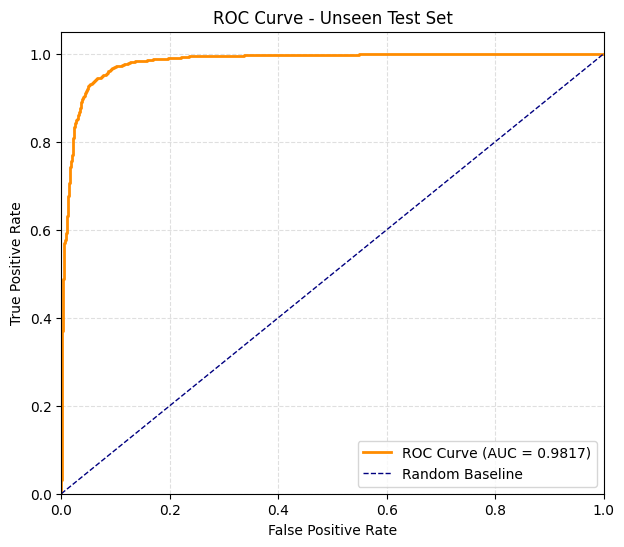

In [3]:
from sklearn.metrics import roc_curve, auc
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# If ROC cell is run directly, rebuild required inputs.
if 'predictions' not in globals() or 'y_true' not in globals():
    print('predictions/y_true not found. Running test inference first...')

    # Resolve model path across Colab and local workspace.
    model_candidates = []
    if 'model_save_path' in globals() and isinstance(model_save_path, str):
        model_candidates.append(model_save_path)

    if 'project_path' in globals() and isinstance(project_path, str):
        model_candidates.append(os.path.join(project_path, 'models', 'malaria_cnn.h5'))

    model_candidates.extend([
        'models/best_model.h5',
        '../models/best_model.h5',
        'models/malaria_cnn.h5',
        '../models/malaria_cnn.h5',
        '/content/drive/My Drive/Colab Notebooks/cv_coursework/models/malaria_cnn.h5'
    ])

    resolved_model_path = next((p for p in model_candidates if os.path.exists(p)), None)
    if resolved_model_path is None:
        raise FileNotFoundError(
            'Could not find a model file. Checked: ' + ', '.join(model_candidates)
        )

    # Resolve test directory across Colab and local workspace.
    test_candidates = []
    if 'test_dir' in globals() and isinstance(test_dir, str):
        test_candidates.append(test_dir)

    test_candidates.extend([
        'data/processed/test',
        '../data/processed/test',
        '/content/split_data/test'
    ])

    resolved_test_dir = next((p for p in test_candidates if os.path.isdir(p)), None)
    if resolved_test_dir is None:
        raise FileNotFoundError(
            'Could not find test directory. Checked: ' + ', '.join(test_candidates)
        )

    if 'IMG_SIZE' not in globals():
        IMG_SIZE = (224, 224)

    if 'BATCH_SIZE' not in globals():
        BATCH_SIZE = 32

    if 'apply_gaussian_blur' not in globals():
        def apply_gaussian_blur(img):
            return img

    best_model = tf.keras.models.load_model(resolved_model_path)

    test_datagen = ImageDataGenerator(
        rescale=1./255,
        preprocessing_function=apply_gaussian_blur
    )

    test_generator = test_datagen.flow_from_directory(
        resolved_test_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )

    predictions = best_model.predict(test_generator)
    y_true = test_generator.classes

# Use probabilities from model output
y_score = predictions.reshape(-1)

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

print(f"AUC Score: {roc_auc:.4f}")

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', linewidth=1, label='Random Baseline')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Unseen Test Set')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()